# Correlation Matrix Analysis

This notebook creates correlation matrices for the three water quality training datasets:
1. DRP Training Dataset
2. EC Training Dataset
3. TA Training Dataset

The correlation matrices help identify relationships between features and can inform feature selection and engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('white')
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Datasets

In [2]:
# Define data path
data_path = Path('../../Datasets_Ours/Final Datasets')

# Load complete datasets (with target variables)
drp_train = pd.read_csv(data_path / 'drp_training_complete.csv')
ec_train = pd.read_csv(data_path / 'ec_training_complete.csv')
ta_train = pd.read_csv(data_path / 'ta_training_complete.csv')

print("Datasets loaded successfully!")
print("="*60)
print(f"DRP Training (Complete): {drp_train.shape}")
print(f"  Target: dissolved_reactive_phosphorus (+ drp_censored_10, drp_censored_20)")
print(f"\nEC Training (Complete): {ec_train.shape}")
print(f"  Target: electrical_conductance")
print(f"\nTA Training (Complete): {ta_train.shape}")
print(f"  Target: total_alkalinity")
print("\nAll columns in DRP dataset:")
print(list(drp_train.columns))

Datasets loaded successfully!
DRP Training (Complete): (9319, 40)
  Target: dissolved_reactive_phosphorus (+ drp_censored_10, drp_censored_20)

EC Training (Complete): (9319, 40)
  Target: electrical_conductance

TA Training (Complete): (9319, 40)
  Target: total_alkalinity

All columns in DRP dataset:
['latitude', 'longitude', 'month_fitted', 'nir', 'green', 'swir16', 'red', 'blue', 'NDMI', 'MNDWI', 'pet', 'aet', 'def', 'q', 'ppt', 'soil', 'srad', 'tmax', 'tmin', 'vap', 'vpd', 'ws', 'pdsi', 'esa_urban_frac_1km', 'esa_cropland_frac_1km', 'esa_water_frac_1km', 'esa_forest_frac_1km', 'esa_bare_frac_1km', 'gsw_occurrence_mean_1km', 'gsw_seasonality_mean_1km', 'gsw_water_frac_1km', 'gaia_impervious_frac_by_sample_year_1km', 'gaia_recent_change_5y_frac_1km', 'dissolved_reactive_phosphorus', 'landsat_present', 'ndvi', 'wb', 'rr', 'seasonal_water', 'gsw_occ_x_impervious']


## 2. Prepare Data for Correlation Analysis

We'll exclude non-numeric columns (latitude, longitude) and focus on the feature correlations.

In [3]:
# Select only numeric columns (exclude latitude and longitude as they're identifiers)
# Keep the target variables for correlation analysis
drp_feature_cols = [col for col in drp_train.columns if col not in ['latitude', 'longitude']]
ec_feature_cols = [col for col in ec_train.columns if col not in ['latitude', 'longitude']]
ta_feature_cols = [col for col in ta_train.columns if col not in ['latitude', 'longitude']]

print(f"Analyzing features (including target variables):")
print("="*60)
print(f"\nDRP dataset: {len(drp_feature_cols)} columns")
print(f"  Features: {len(drp_feature_cols) - 3}")
print(f"  Target: dissolved_reactive_phosphorus")
print(f"  Indicators: drp_censored_10, drp_censored_20")

print(f"\nEC dataset: {len(ec_feature_cols)} columns")
print(f"  Features: {len(ec_feature_cols) - 1}")
print(f"  Target: electrical_conductance")

print(f"\nTA dataset: {len(ta_feature_cols)} columns")
print(f"  Features: {len(ta_feature_cols) - 1}")
print(f"  Target: total_alkalinity")

# Extract feature data
drp_features = drp_train[drp_feature_cols]
ec_features = ec_train[ec_feature_cols]
ta_features = ta_train[ta_feature_cols]

print(f"\nFeature data shapes:")
print(f"DRP: {drp_features.shape}")
print(f"EC: {ec_features.shape}")
print(f"TA: {ta_features.shape}")

Analyzing features (including target variables):

DRP dataset: 38 columns
  Features: 35
  Target: dissolved_reactive_phosphorus
  Indicators: drp_censored_10, drp_censored_20

EC dataset: 38 columns
  Features: 37
  Target: electrical_conductance

TA dataset: 38 columns
  Features: 37
  Target: total_alkalinity

Feature data shapes:
DRP: (9319, 38)
EC: (9319, 38)
TA: (9319, 38)


## 3. Calculate Correlation Matrices

In [4]:
# Calculate correlation matrices
drp_corr = drp_features.corr()
ec_corr = ec_features.corr()
ta_corr = ta_features.corr()

print("Correlation matrices calculated!")
print(f"\nDRP correlation matrix shape: {drp_corr.shape}")
print(f"EC correlation matrix shape: {ec_corr.shape}")
print(f"TA correlation matrix shape: {ta_corr.shape}")

Correlation matrices calculated!

DRP correlation matrix shape: (38, 38)
EC correlation matrix shape: (38, 38)
TA correlation matrix shape: (38, 38)


## 4. Visualize DRP Training Correlation Matrix

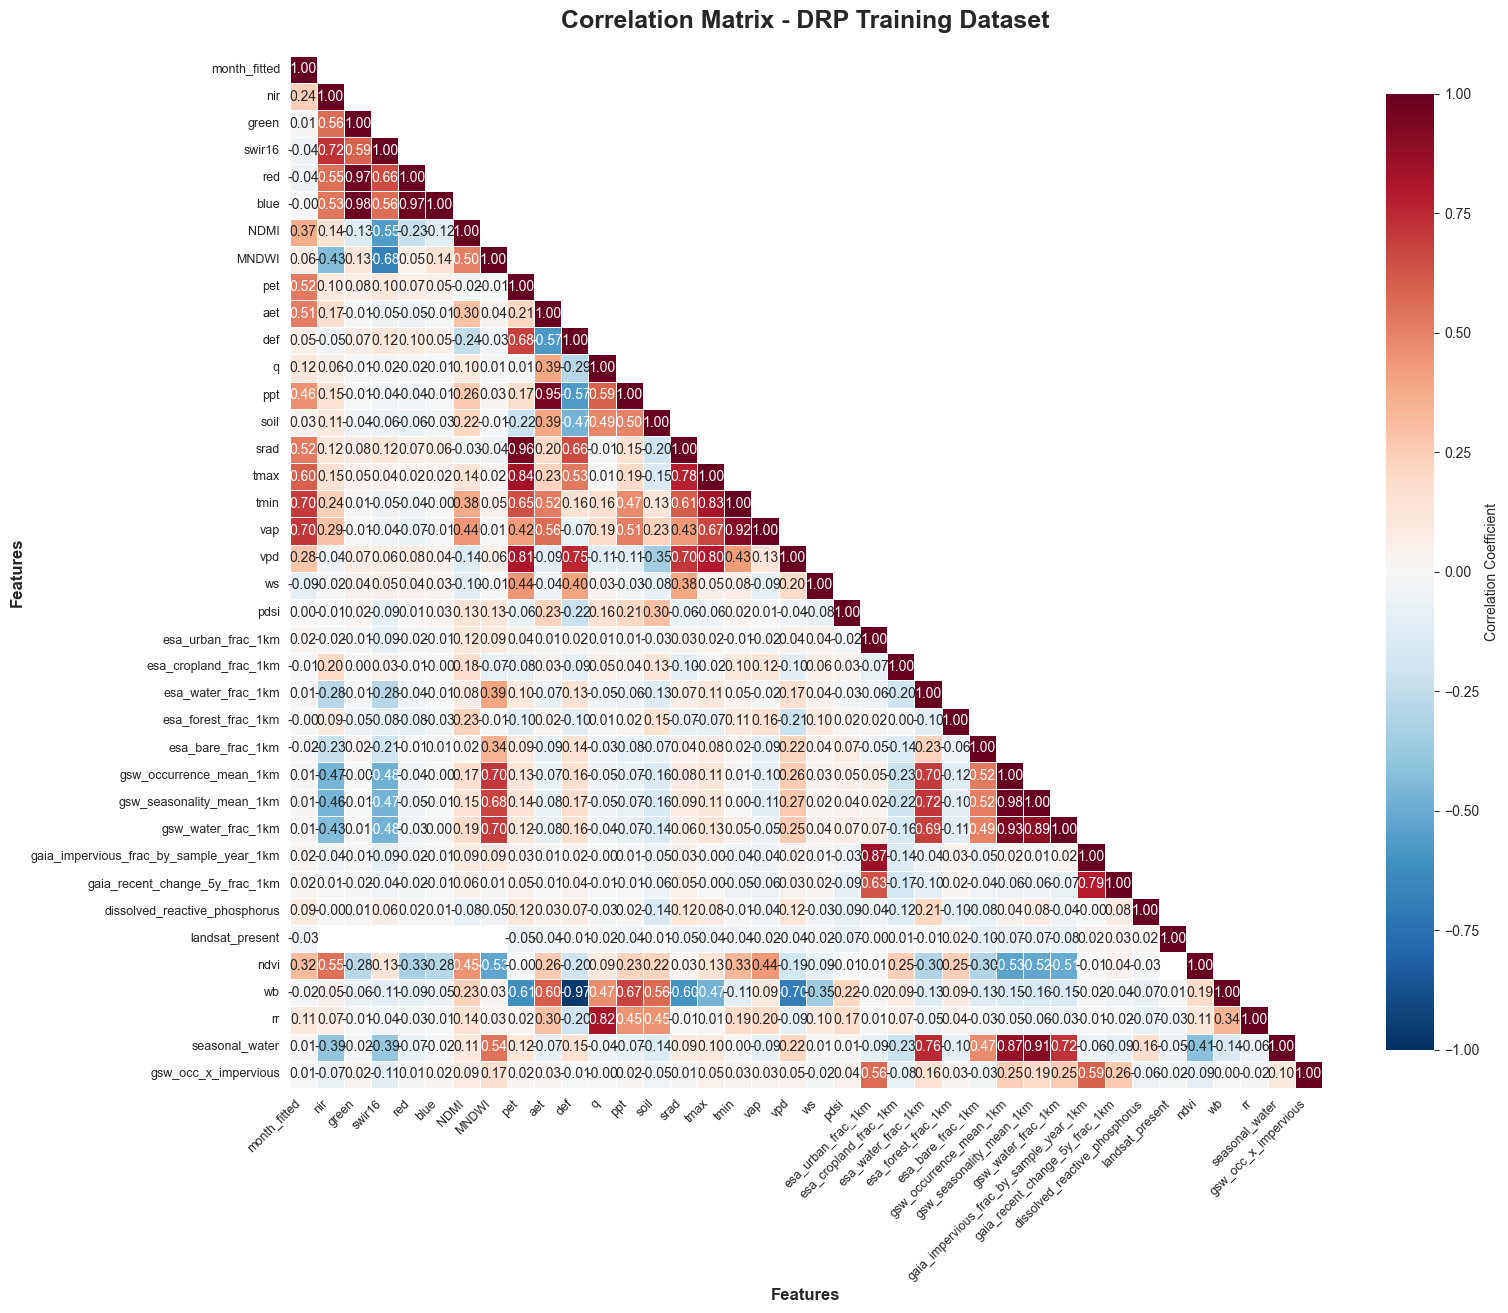


Highly correlated feature pairs in DRP dataset (|r| > 0.7):
green                     <-> blue                     : r =  0.980
gsw_occurrence_mean_1km   <-> gsw_seasonality_mean_1km : r =  0.978
green                     <-> red                      : r =  0.974
red                       <-> blue                     : r =  0.972
def                       <-> wb                       : r = -0.965
pet                       <-> srad                     : r =  0.957
aet                       <-> ppt                      : r =  0.949
gsw_occurrence_mean_1km   <-> gsw_water_frac_1km       : r =  0.934
tmin                      <-> vap                      : r =  0.918
gsw_seasonality_mean_1km  <-> seasonal_water           : r =  0.914
gsw_seasonality_mean_1km  <-> gsw_water_frac_1km       : r =  0.890
gsw_occurrence_mean_1km   <-> seasonal_water           : r =  0.870
esa_urban_frac_1km        <-> gaia_impervious_frac_by_sample_year_1km: r =  0.866
pet                       <-> tmax       

In [5]:
# Create DRP correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Create mask for upper triangle (optional - shows only lower half)
mask = np.triu(np.ones_like(drp_corr, dtype=bool), k=1)

# Create heatmap
sns.heatmap(drp_corr, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            ax=ax)

plt.title('Correlation Matrix - DRP Training Dataset', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs (|r| > 0.7, excluding diagonal)
print("\nHighly correlated feature pairs in DRP dataset (|r| > 0.7):")
print("="*70)
high_corr = []
for i in range(len(drp_corr.columns)):
    for j in range(i+1, len(drp_corr.columns)):
        if abs(drp_corr.iloc[i, j]) > 0.7:
            high_corr.append((drp_corr.columns[i], drp_corr.columns[j], drp_corr.iloc[i, j]))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr in high_corr:
    print(f"{feat1:25s} <-> {feat2:25s}: r = {corr:6.3f}")

## 5. Visualize EC Training Correlation Matrix

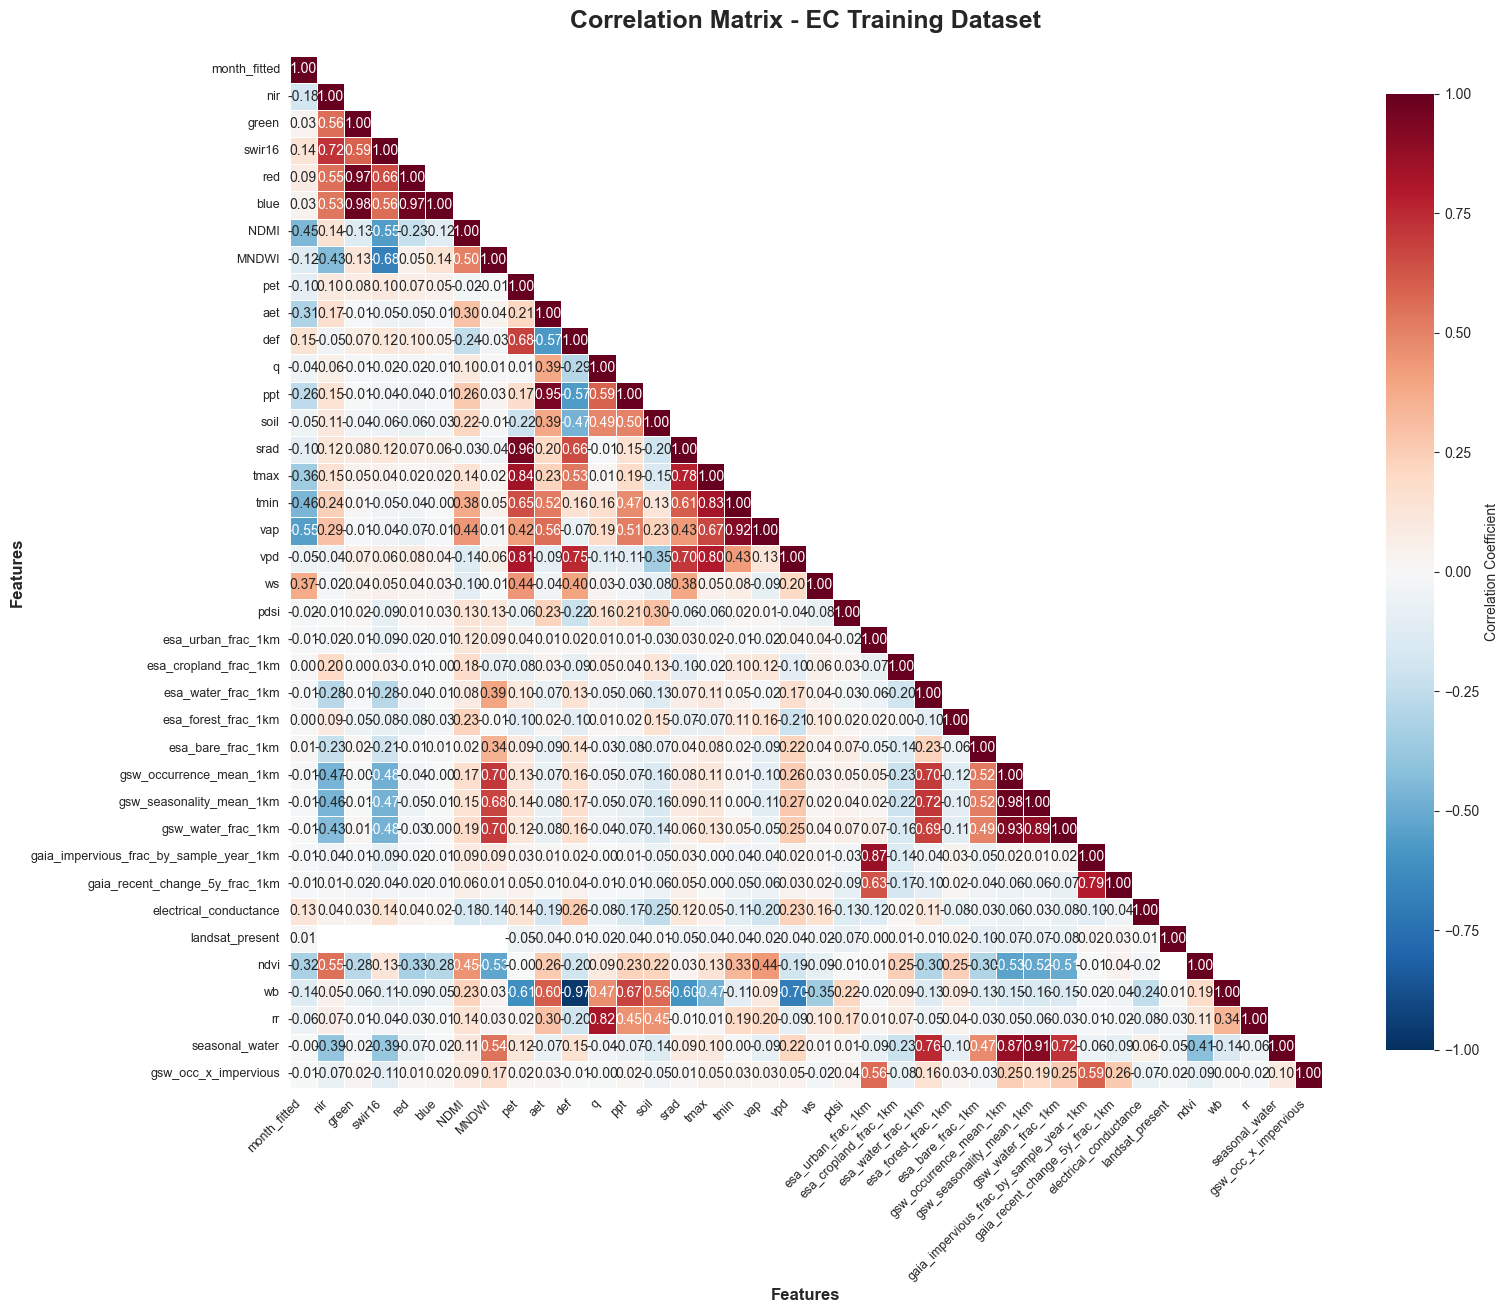


Highly correlated feature pairs in EC dataset (|r| > 0.7):
green                     <-> blue                     : r =  0.980
gsw_occurrence_mean_1km   <-> gsw_seasonality_mean_1km : r =  0.978
green                     <-> red                      : r =  0.974
red                       <-> blue                     : r =  0.972
def                       <-> wb                       : r = -0.965
pet                       <-> srad                     : r =  0.957
aet                       <-> ppt                      : r =  0.949
gsw_occurrence_mean_1km   <-> gsw_water_frac_1km       : r =  0.934
tmin                      <-> vap                      : r =  0.918
gsw_seasonality_mean_1km  <-> seasonal_water           : r =  0.914
gsw_seasonality_mean_1km  <-> gsw_water_frac_1km       : r =  0.890
gsw_occurrence_mean_1km   <-> seasonal_water           : r =  0.870
esa_urban_frac_1km        <-> gaia_impervious_frac_by_sample_year_1km: r =  0.866
pet                       <-> tmax        

In [6]:
# Create EC correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Create mask for upper triangle
mask = np.triu(np.ones_like(ec_corr, dtype=bool), k=1)

# Create heatmap
sns.heatmap(ec_corr, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            ax=ax)

plt.title('Correlation Matrix - EC Training Dataset', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
print("\nHighly correlated feature pairs in EC dataset (|r| > 0.7):")
print("="*70)
high_corr = []
for i in range(len(ec_corr.columns)):
    for j in range(i+1, len(ec_corr.columns)):
        if abs(ec_corr.iloc[i, j]) > 0.7:
            high_corr.append((ec_corr.columns[i], ec_corr.columns[j], ec_corr.iloc[i, j]))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr in high_corr:
    print(f"{feat1:25s} <-> {feat2:25s}: r = {corr:6.3f}")

## 6. Visualize TA Training Correlation Matrix

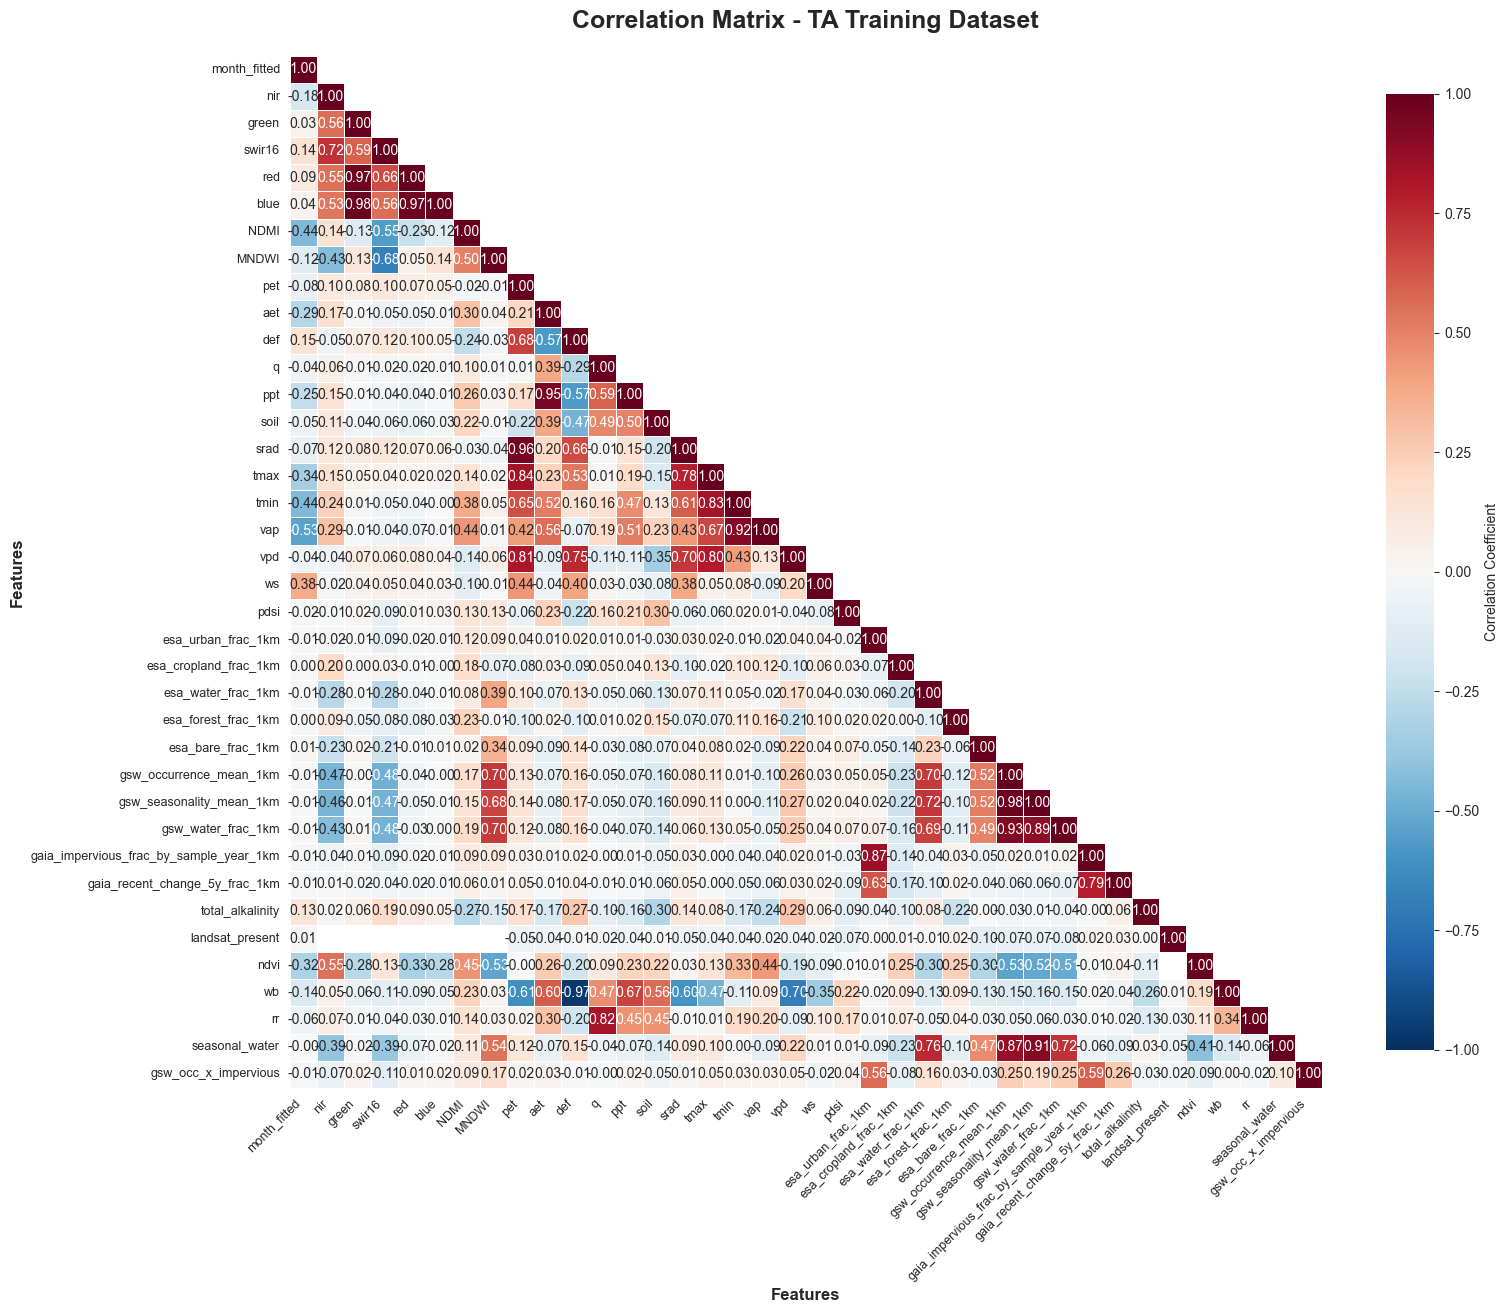


Highly correlated feature pairs in TA dataset (|r| > 0.7):
green                     <-> blue                     : r =  0.980
gsw_occurrence_mean_1km   <-> gsw_seasonality_mean_1km : r =  0.978
green                     <-> red                      : r =  0.974
red                       <-> blue                     : r =  0.972
def                       <-> wb                       : r = -0.965
pet                       <-> srad                     : r =  0.957
aet                       <-> ppt                      : r =  0.949
gsw_occurrence_mean_1km   <-> gsw_water_frac_1km       : r =  0.934
tmin                      <-> vap                      : r =  0.918
gsw_seasonality_mean_1km  <-> seasonal_water           : r =  0.914
gsw_seasonality_mean_1km  <-> gsw_water_frac_1km       : r =  0.890
gsw_occurrence_mean_1km   <-> seasonal_water           : r =  0.870
esa_urban_frac_1km        <-> gaia_impervious_frac_by_sample_year_1km: r =  0.866
pet                       <-> tmax        

In [7]:
# Create TA correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Create mask for upper triangle
mask = np.triu(np.ones_like(ta_corr, dtype=bool), k=1)

# Create heatmap
sns.heatmap(ta_corr, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
            ax=ax)

plt.title('Correlation Matrix - TA Training Dataset', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
print("\nHighly correlated feature pairs in TA dataset (|r| > 0.7):")
print("="*70)
high_corr = []
for i in range(len(ta_corr.columns)):
    for j in range(i+1, len(ta_corr.columns)):
        if abs(ta_corr.iloc[i, j]) > 0.7:
            high_corr.append((ta_corr.columns[i], ta_corr.columns[j], ta_corr.iloc[i, j]))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr in high_corr:
    print(f"{feat1:25s} <-> {feat2:25s}: r = {corr:6.3f}")

## 7. Compare Correlation Patterns Across Datasets

Let's examine if certain feature pairs show consistent correlations across all three datasets.

In [8]:
print("\n" + "="*80)
print("COMPARISON: Feature Correlations Across All Three Datasets")
print("="*80)

# Find common features across all three datasets (excluding target variables)
drp_features_only = [col for col in drp_corr.columns if col not in ['dissolved_reactive_phosphorus', 'drp_censored_10', 'drp_censored_20']]
ec_features_only = [col for col in ec_corr.columns if col != 'electrical_conductance']
ta_features_only = [col for col in ta_corr.columns if col != 'total_alkalinity']

# Find features common to all three datasets
common_features = list(set(drp_features_only) & set(ec_features_only) & set(ta_features_only))
common_features.sort()  # Sort for consistent ordering

print(f"\nCommon features across all datasets: {len(common_features)}")
print(f"(Excluding target-specific columns)")

# Create sub-correlation matrices with only common features
drp_corr_common = drp_corr.loc[common_features, common_features]
ec_corr_common = ec_corr.loc[common_features, common_features]
ta_corr_common = ta_corr.loc[common_features, common_features]

# Find feature pairs that are highly correlated in all three datasets
common_high_corr = []

for i in range(len(common_features)):
    for j in range(i+1, len(common_features)):
        drp_r = drp_corr_common.iloc[i, j]
        ec_r = ec_corr_common.iloc[i, j]
        ta_r = ta_corr_common.iloc[i, j]
        
        # If all three have |r| > 0.7
        if abs(drp_r) > 0.7 and abs(ec_r) > 0.7 and abs(ta_r) > 0.7:
            common_high_corr.append({
                'feature_1': common_features[i],
                'feature_2': common_features[j],
                'drp_r': drp_r,
                'ec_r': ec_r,
                'ta_r': ta_r,
                'avg_r': (abs(drp_r) + abs(ec_r) + abs(ta_r)) / 3
            })

if common_high_corr:
    common_df = pd.DataFrame(common_high_corr).sort_values('avg_r', ascending=False)
    print("\nFeature pairs with strong correlation (|r| > 0.7) across ALL datasets:")
    print("-"*80)
    for _, row in common_df.iterrows():
        print(f"\n{row['feature_1']} <-> {row['feature_2']}")
        print(f"  DRP: {row['drp_r']:6.3f} | EC: {row['ec_r']:6.3f} | TA: {row['ta_r']:6.3f} | Avg: {row['avg_r']:6.3f}")
else:
    print("\nNo feature pairs show strong correlation (|r| > 0.7) across all three datasets.")

# Look at moderate correlations (0.5 < |r| < 0.9) that are consistent
print("\n" + "="*80)
print("Feature pairs with moderate-to-strong correlation (0.5 < |r| < 0.9) consistent across datasets:")
print("="*80)

moderate_corr = []
for i in range(len(common_features)):
    for j in range(i+1, len(common_features)):
        drp_r = drp_corr_common.iloc[i, j]
        ec_r = ec_corr_common.iloc[i, j]
        ta_r = ta_corr_common.iloc[i, j]
        
        # All three have moderate to strong correlation and same sign
        if (0.5 < abs(drp_r) < 0.9 and 0.5 < abs(ec_r) < 0.9 and 0.5 < abs(ta_r) < 0.9 and
            np.sign(drp_r) == np.sign(ec_r) == np.sign(ta_r)):
            moderate_corr.append({
                'feature_1': common_features[i],
                'feature_2': common_features[j],
                'drp_r': drp_r,
                'ec_r': ec_r,
                'ta_r': ta_r,
                'avg_r': (abs(drp_r) + abs(ec_r) + abs(ta_r)) / 3
            })

if moderate_corr:
    moderate_df = pd.DataFrame(moderate_corr).sort_values('avg_r', ascending=False)
    print(f"\nFound {len(moderate_df)} feature pairs with consistent moderate correlation:")
    print("-"*80)
    for _, row in moderate_df.head(10).iterrows():  # Show top 10
        print(f"\n{row['feature_1']} <-> {row['feature_2']}")
        print(f"  DRP: {row['drp_r']:6.3f} | EC: {row['ec_r']:6.3f} | TA: {row['ta_r']:6.3f} | Avg: {row['avg_r']:6.3f}")
else:
    print("\nNo consistent moderate correlations found.")


COMPARISON: Feature Correlations Across All Three Datasets

Common features across all datasets: 37
(Excluding target-specific columns)

Feature pairs with strong correlation (|r| > 0.7) across ALL datasets:
--------------------------------------------------------------------------------

blue <-> green
  DRP:  0.980 | EC:  0.980 | TA:  0.980 | Avg:  0.980

gsw_occurrence_mean_1km <-> gsw_seasonality_mean_1km
  DRP:  0.978 | EC:  0.978 | TA:  0.978 | Avg:  0.978

green <-> red
  DRP:  0.974 | EC:  0.974 | TA:  0.974 | Avg:  0.974

blue <-> red
  DRP:  0.972 | EC:  0.972 | TA:  0.972 | Avg:  0.972

def <-> wb
  DRP: -0.965 | EC: -0.965 | TA: -0.965 | Avg:  0.965

pet <-> srad
  DRP:  0.957 | EC:  0.957 | TA:  0.957 | Avg:  0.957

aet <-> ppt
  DRP:  0.949 | EC:  0.949 | TA:  0.949 | Avg:  0.949

gsw_occurrence_mean_1km <-> gsw_water_frac_1km
  DRP:  0.934 | EC:  0.934 | TA:  0.934 | Avg:  0.934

tmin <-> vap
  DRP:  0.918 | EC:  0.918 | TA:  0.918 | Avg:  0.918

gsw_seasonality_mean_1k

## 8. Feature Correlations with Target Variables

Let's examine which features are most strongly correlated with each target variable.


Top 15 Features Correlated with dissolved_reactive_phosphorus (DRP Dataset)
 1. esa_water_frac_1km            : r =  0.2063
 2. seasonal_water                : r =  0.1645
 3. soil                          : r = -0.1445
 4. vpd                           : r =  0.1240
 5. srad                          : r =  0.1225
 6. esa_cropland_frac_1km         : r = -0.1219
 7. pet                           : r =  0.1167
 8. esa_forest_frac_1km           : r = -0.0969
 9. pdsi                          : r = -0.0921
10. month_fitted                  : r =  0.0882
11. gaia_recent_change_5y_frac_1km: r =  0.0841
12. NDMI                          : r = -0.0827
13. gsw_seasonality_mean_1km      : r =  0.0812
14. esa_bare_frac_1km             : r = -0.0806
15. tmax                          : r =  0.0805


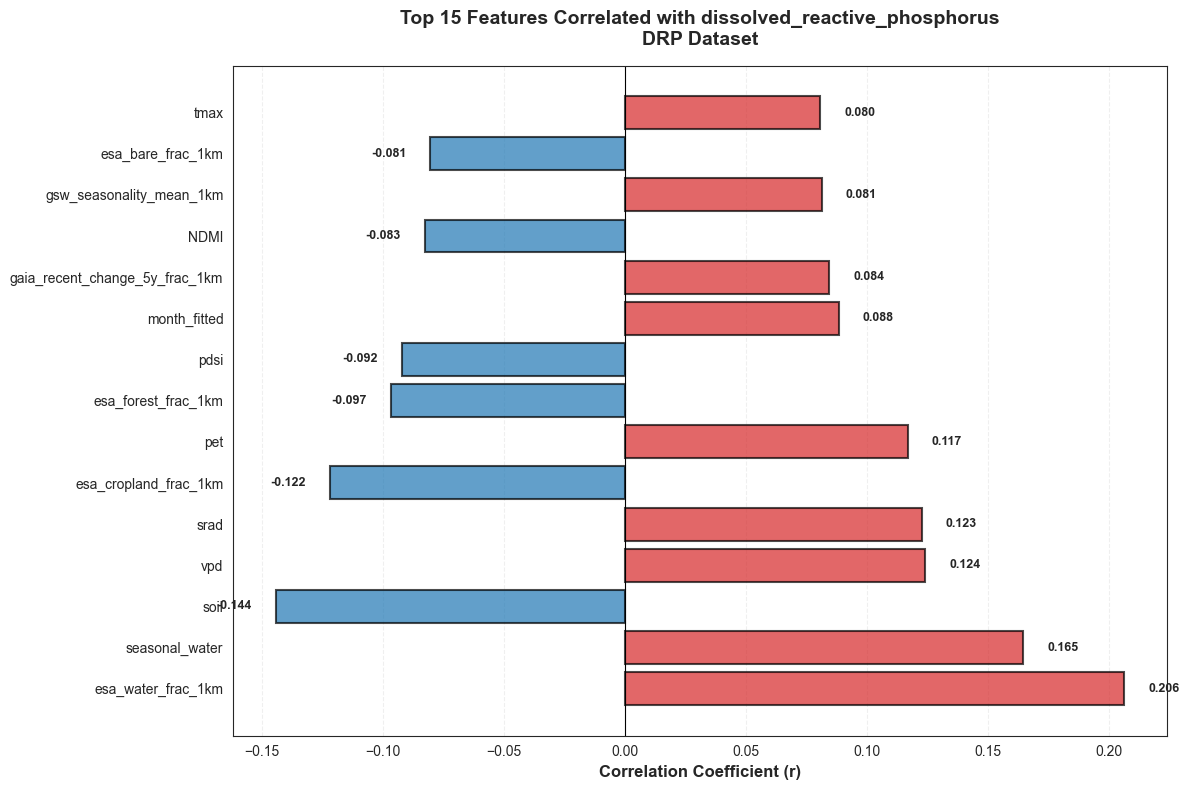


Top 15 Features Correlated with electrical_conductance (EC Dataset)
 1. def                           : r =  0.2597
 2. soil                          : r = -0.2518
 3. wb                            : r = -0.2435
 4. vpd                           : r =  0.2300
 5. vap                           : r = -0.1971
 6. aet                           : r = -0.1869
 7. NDMI                          : r = -0.1775
 8. ppt                           : r = -0.1697
 9. ws                            : r =  0.1622
10. swir16                        : r =  0.1447
11. pet                           : r =  0.1426
12. MNDWI                         : r = -0.1416
13. pdsi                          : r = -0.1344
14. month_fitted                  : r =  0.1301
15. esa_urban_frac_1km            : r = -0.1208


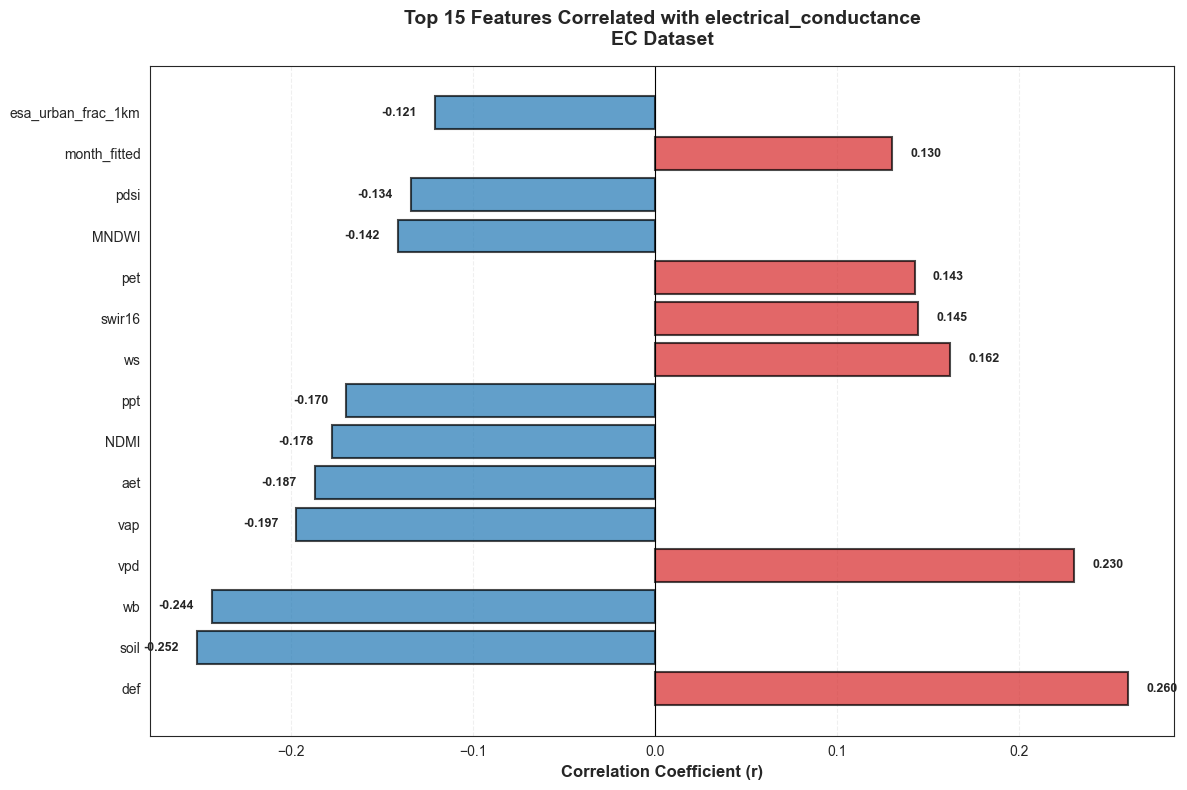


Top 15 Features Correlated with total_alkalinity (TA Dataset)
 1. soil                          : r = -0.2972
 2. vpd                           : r =  0.2873
 3. NDMI                          : r = -0.2741
 4. def                           : r =  0.2697
 5. wb                            : r = -0.2551
 6. vap                           : r = -0.2442
 7. esa_forest_frac_1km           : r = -0.2196
 8. swir16                        : r =  0.1919
 9. tmin                          : r = -0.1710
10. aet                           : r = -0.1706
11. pet                           : r =  0.1691
12. ppt                           : r = -0.1593
13. MNDWI                         : r = -0.1546
14. srad                          : r =  0.1403
15. rr                            : r = -0.1332


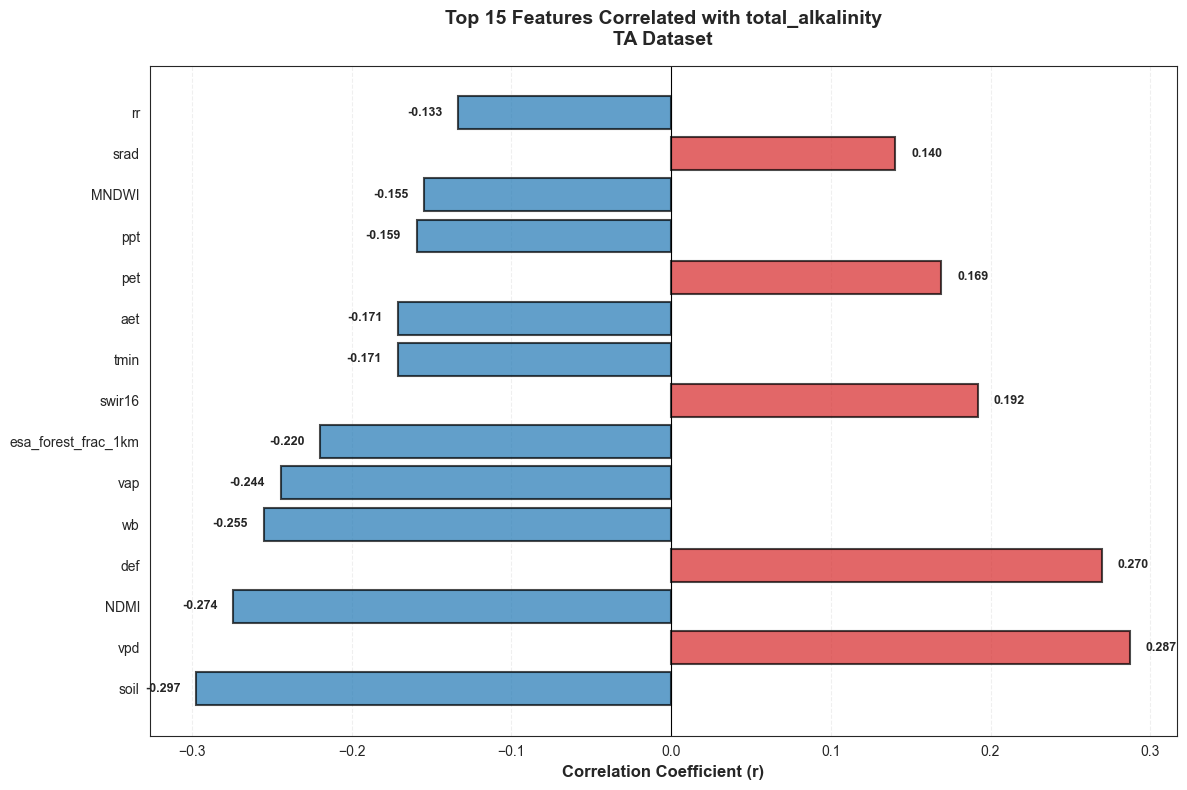

In [9]:
def analyze_target_correlations(df, target_col, dataset_name, top_n=15):
    """
    Analyze and visualize correlations between features and the target variable
    """
    # Calculate correlations with target
    correlations = df.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    
    print(f"\n{'='*80}")
    print(f"Top {top_n} Features Correlated with {target_col} ({dataset_name})")
    print(f"{'='*80}")
    
    top_corr = correlations.head(top_n)
    for i, (feature, corr) in enumerate(top_corr.items(), 1):
        print(f"{i:2d}. {feature:30s}: r = {corr:7.4f}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create color array (positive = red, negative = blue)
    colors = ['#d62728' if x > 0 else '#1f77b4' for x in top_corr.values]
    
    # Create horizontal bar plot
    y_pos = np.arange(len(top_corr))
    ax.barh(y_pos, top_corr.values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_corr.index, fontsize=10)
    ax.set_xlabel('Correlation Coefficient (r)', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Features Correlated with {target_col}\n{dataset_name}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Add correlation values on bars
    for i, (idx, val) in enumerate(top_corr.items()):
        ax.text(val + (0.01 if val > 0 else -0.01), i, f'{val:.3f}', 
                va='center', ha='left' if val > 0 else 'right', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return top_corr

# Analyze each target variable
drp_target_corr = analyze_target_correlations(drp_features, 'dissolved_reactive_phosphorus', 'DRP Dataset', top_n=15)
ec_target_corr = analyze_target_correlations(ec_features, 'electrical_conductance', 'EC Dataset', top_n=15)
ta_target_corr = analyze_target_correlations(ta_features, 'total_alkalinity', 'TA Dataset', top_n=15)

## 9. Side-by-Side Comparison (Compact View)

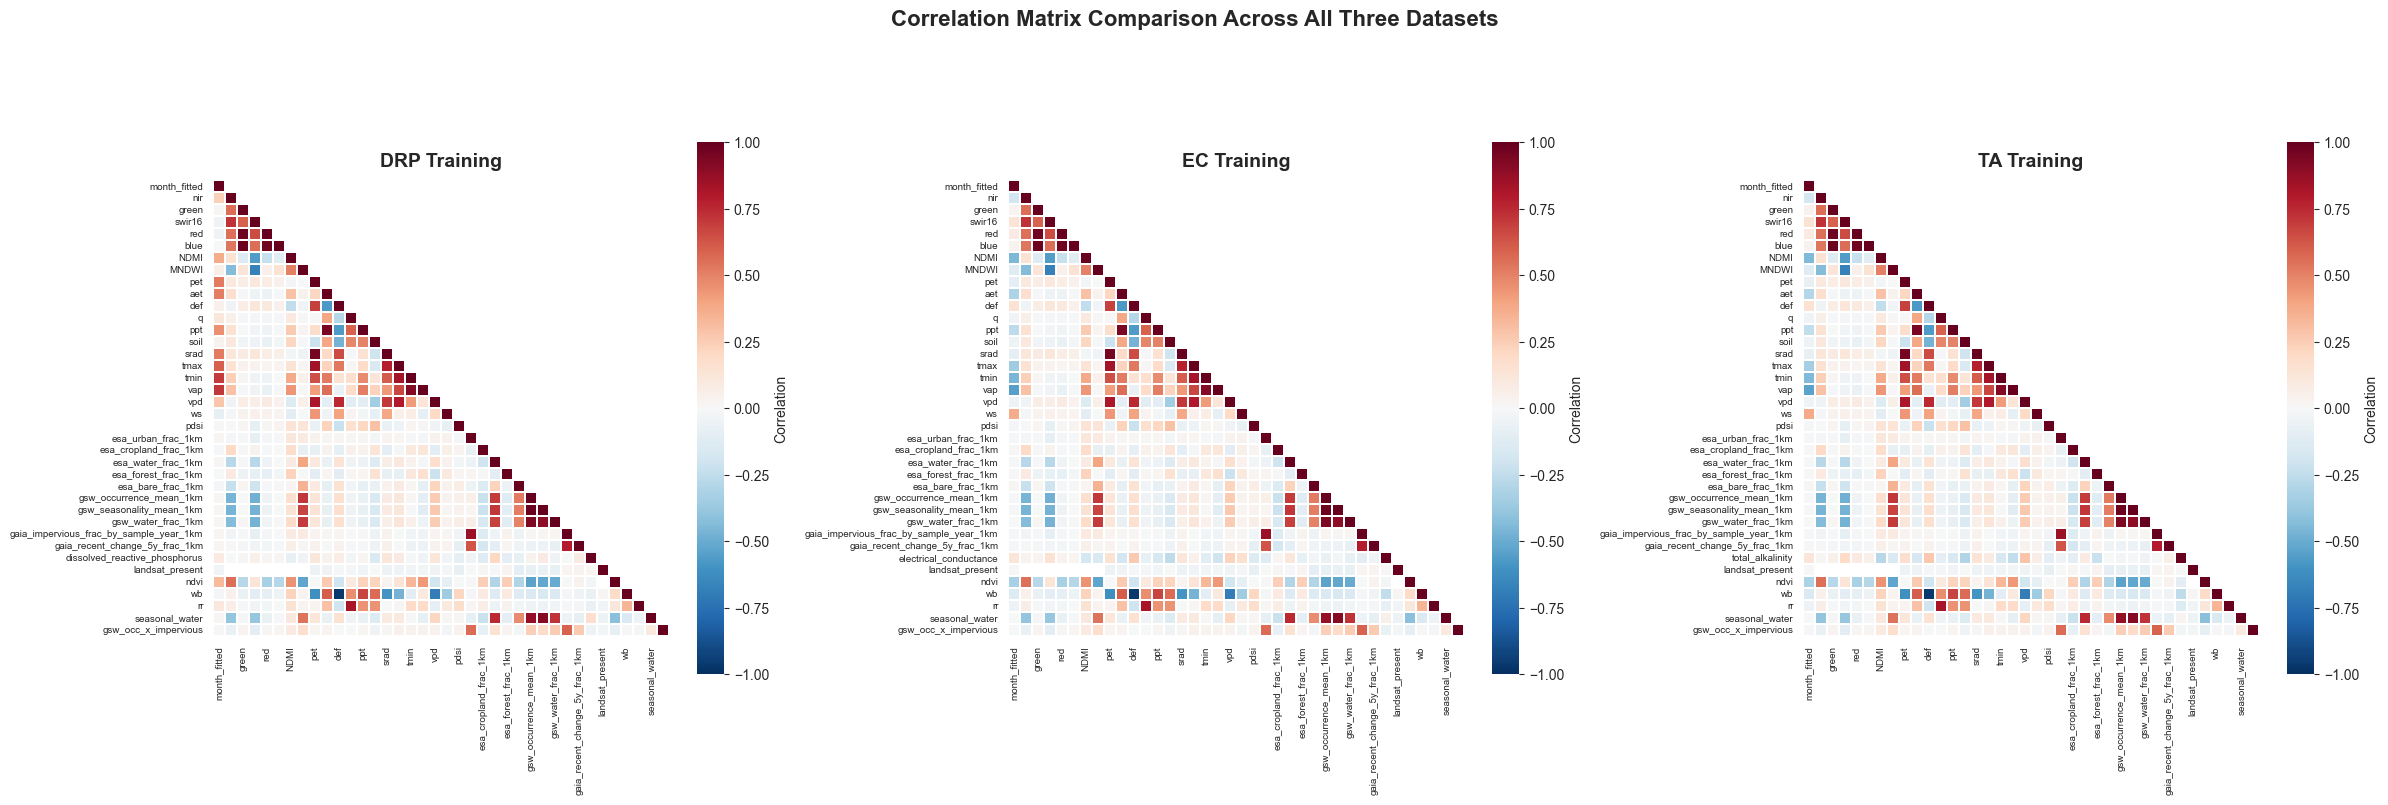


✓ Correlation analysis complete!


In [10]:
# Create a compact side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# DRP
mask = np.triu(np.ones_like(drp_corr, dtype=bool), k=1)
sns.heatmap(drp_corr, mask=mask, annot=False, cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.1, ax=axes[0],
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
axes[0].set_title('DRP Training', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='both', labelsize=7)

# EC
mask = np.triu(np.ones_like(ec_corr, dtype=bool), k=1)
sns.heatmap(ec_corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.1, ax=axes[1],
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
axes[1].set_title('EC Training', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=7)

# TA
mask = np.triu(np.ones_like(ta_corr, dtype=bool), k=1)
sns.heatmap(ta_corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.1, ax=axes[2],
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
axes[2].set_title('TA Training', fontsize=14, fontweight='bold', pad=10)
axes[2].set_xlabel('')
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=7)

fig.suptitle('Correlation Matrix Comparison Across All Three Datasets', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Correlation analysis complete!")

## Summary

This notebook provides comprehensive correlation analysis for all three water quality training datasets:

**Datasets Analyzed:**
1. DRP Training Complete (9,319 samples × 28 features including target)
2. EC Training Complete (9,319 samples × 26 features including target)
3. TA Training Complete (9,319 samples × 26 features including target)

**Key Analyses:**
1. ✅ Individual correlation matrices for DRP, EC, and TA datasets
2. ✅ Lists of highly correlated feature pairs (|r| > 0.7) for each dataset
3. ✅ Comparison of correlation patterns across datasets
4. ✅ **Feature correlations with target variables** (NEW!)
5. ✅ Side-by-side visualization for easy comparison

**Color Scheme:**
- 🔴 Red: Strong positive correlation
- 🔵 Blue: Strong negative correlation
- ⚪ White: No correlation

**Key Insights for Feature Engineering:**
- Identify which features are most predictive of each target variable
- Detect multicollinearity (highly correlated features)
- Understand relationships between environmental variables
- Inform feature selection for modeling

**Use these insights for:**
- Feature selection (remove highly correlated features to reduce multicollinearity)
- Feature engineering (combine correlated features)
- Model interpretation (understand which features drive predictions)
- Understanding environmental relationships